<h2>Generate and interpret comprehensive correlation heatmaps, including Pearson, Spearman, and Kendall correlations, to identify linear and non-linear relationships between variables and uncover multicollinearity issues.</h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
medicines = pd.read_csv('medicines_cleaned.csv')

In [3]:
medicines

,id,name,generic_name,category,description,strength,dosage_form,purchase_price,selling_price,mrp,...,supplier,manufacturer,is_prescription_required,is_seasonal,season_category,purchase_price_num,selling_price_num,mrp_num,selling_price_cleaned,current_stock_cleaned
0,Amoxicillin,Antibiotics,Broad-spectrum antibiotic for bacterial infect...,urinary tract,and skin infections.,500mg,Capsule,12.0,25.0,30.0,...,Cipla Limited,Cipla Limited,TRUE,False,NaN,12.0,25.0,30.0,25.0,120.0
1,Azithromycin,Antibiotics,Antibiotic for respiratory infections,skin infections,and ear infections.,500mg,Tablet,40.0,65.0,75.0,...,Sun Pharma,Sun Pharma,TRUE,True,Monsoon,40.0,65.0,75.0,65.0,85.0
2,Ciprofloxacin,Antibiotics,Broad-spectrum antibiotic for urinary tract in...,respiratory infections.,500mg,Tablet,25.00,45.0,55.0,60.0,...,Dr. Reddy's,TRUE,FALSE,NaN,NaN,45.0,55.0,60.0,55.0,10.0
3,Doxycycline,Antibiotics,Tetracycline antibiotic for bacterial infections,acne,and malaria prophylaxis.,100mg,Capsule,18.0,35.0,42.0,...,Glenmark,Glenmark,TRUE,True,Summer,18.0,35.0,42.0,35.0,95.0
4,Metronidazole,Antibiotics,Antibiotic for anaerobic bacterial infections ...,400mg,Tablet,8.00,15.00,20.0,150.0,25.0,...,TRUE,FALSE,NaN,NaN,NaN,20.0,150.0,25.0,25.0,95.0
5,Metformin,Antidiabetics,First-line medication for type 2 diabetes. Red...,500mg,Tablet,5.00,10.00,15.0,200.0,30.0,...,TRUE,FALSE,NaN,NaN,NaN,15.0,200.0,30.0,30.0,95.0
6,Glimepiride,Antidiabetics,Sulfonylurea medication for type 2 diabetes.,2mg,Tablet,8.00,16.00,22.0,120.0,20.0,...,TRUE,FALSE,NaN,NaN,NaN,22.0,120.0,20.0,20.0,95.0
7,Empagliflozin,Antidiabetics,SGLT2 inhibitor for type 2 diabetes.,25mg,Tablet,50.00,85.00,100.0,55.0,10.0,...,TRUE,FALSE,NaN,NaN,NaN,100.0,55.0,10.0,10.0,95.0
8,Amlodipine,Antihypertensives,Calcium channel blocker for hypertension and a...,5mg,Tablet,4.00,8.00,12.0,180.0,25.0,...,TRUE,FALSE,NaN,NaN,NaN,12.0,180.0,25.0,25.0,95.0
9,Losartan,Antihypertensives,ARB for hypertension and diabetic nephropathy.,50mg,Tablet,6.00,12.00,18.0,150.0,20.0,...,TRUE,FALSE,NaN,NaN,NaN,18.0,150.0,20.0,20.0,95.0


In [5]:
medicines['purchase_price'] = pd.to_numeric(medicines['purchase_price'], errors='coerce')
medicines['mrp'] = pd.to_numeric(medicines['mrp'], errors='coerce')
medicines['selling_price_clean'] = np.minimum(
    pd.to_numeric(medicines['selling_price'], errors='coerce'), 
    medicines['mrp']
)
medicines['current_stock_clean'] = pd.to_numeric(medicines['current_stock'], errors='coerce')

In [6]:
med_df = medicines[['purchase_price', 'selling_price_clean', 'mrp', 'current_stock_clean']].dropna()
med_df.columns = ['Purchase Price', 'Selling Price', 'MRP', 'Current Stock']

In [7]:
pearson_corr = med_df.corr(method='pearson')
spearman_corr = med_df.corr(method='spearman')
kendall_corr = med_df.corr(method='kendall')

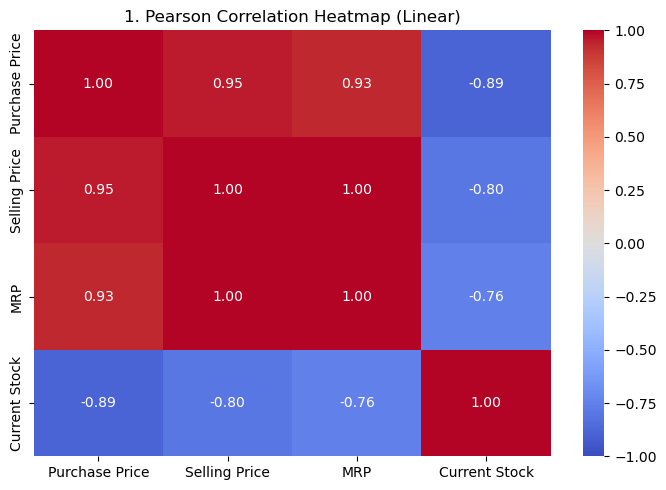

In [10]:
plt.figure(figsize=(7, 5))
sns.heatmap(med_df.corr(method='pearson'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("1. Pearson Correlation Heatmap (Linear)")
plt.tight_layout()
plt.show()

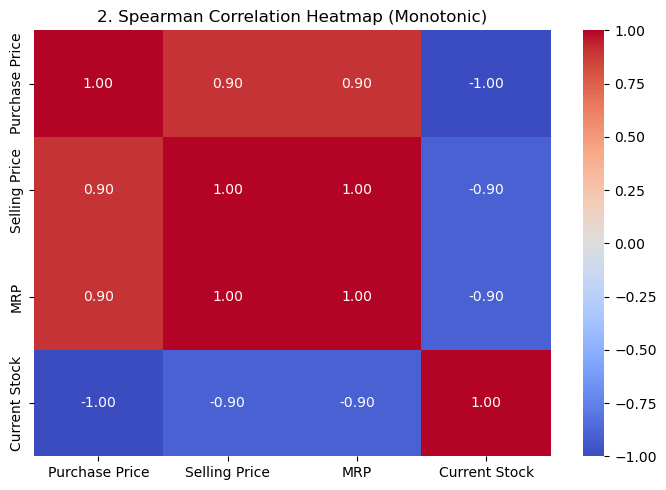

In [11]:
plt.figure(figsize=(7, 5))
sns.heatmap(med_df.corr(method='spearman'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("2. Spearman Correlation Heatmap (Monotonic)")
plt.tight_layout()
plt.show()

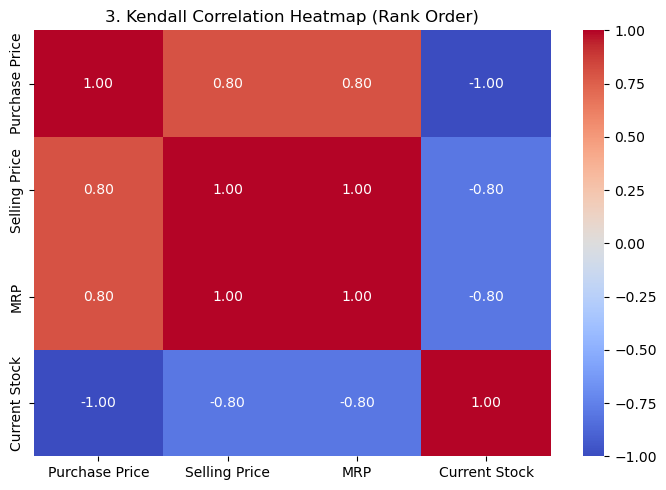

In [12]:
plt.figure(figsize=(7, 5))
sns.heatmap(med_df.corr(method='kendall'), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("3. Kendall Correlation Heatmap (Rank Order)")
plt.tight_layout()
plt.show()